# Carleton evacuation — MARS

Set `SCENARIO` (1–8) and `RUN_SIMULATION` below, then run all cells.

| # | Scenario |
|---|----------|
| 1 | Baseline |
| 2 | P6 +1 h |
| 3 | P6 +2 h |
| 4 | P3 +1 h, P6 +2 h |
| 5 | P3/P4 +1 h, P6 +2 h |
| 6 | P3/P4 +1 h, P6 +1.5 h |
| 7 | Baseline timing; P3/P4 emergency exit |
| 8 | Baseline timing; Bronson exit blocked; all lots → Colonel By |

**Step 1** — Load the project folder and helpers for running commands.

In [8]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path

from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "SOHCarletonDrivingBox.csproj").is_file():
    candidate = ROOT / "CarletonDrivingBox"
    if (candidate / "SOHCarletonDrivingBox.csproj").is_file():
        ROOT = candidate

os.chdir(ROOT)

SCRIPTS = ROOT / "scripts"
RESULTS = ROOT / "results"
CONFIGS = ROOT / "configs"
PROJECT = "SOHCarletonDrivingBox.csproj"

sys.path.insert(0, str(SCRIPTS))
from mars_agent_outputs import agent_output_path


def config_arg(config: Path) -> str:
    """POSIX-relative config path for dotnet (works on Windows and Mac)."""
    return config.relative_to(ROOT).as_posix()


def run_cmd(cmd: list[str], *, quiet: bool = False, label: str | None = None) -> None:
    if label:
        print(label, flush=True)
    elif not quiet:
        print("Running:", " ".join(cmd), flush=True)
    completed = subprocess.run(
        cmd,
        cwd=ROOT,
        env={**os.environ, "DOTNET_NOLOGO": "1"},
        capture_output=quiet,
        text=True,
    )
    if completed.returncode != 0:
        details = ""
        if quiet:
            details = "\n" + (completed.stdout or "") + (completed.stderr or "")
        raise RuntimeError(
            f"Command failed ({completed.returncode}): {' '.join(cmd)}{details}"
        )
    if quiet:
        print("  done.", flush=True)


def run_simulation_cmd(cmd: list[str], *, label: str = "Running simulation…") -> subprocess.CompletedProcess:
    """Run MARS with a real console (ProgressBar needs one when console:true)."""
    print(label, flush=True)
    kwargs: dict = {
        "cwd": ROOT,
        "env": {**os.environ, "DOTNET_NOLOGO": "1"},
    }
    if sys.platform == "win32":
        kwargs["creationflags"] = subprocess.CREATE_NEW_CONSOLE
    else:
        kwargs["stdout"] = None
        kwargs["stderr"] = None
    return subprocess.run(cmd, **kwargs)


assert (ROOT / PROJECT).is_file(), f"Open this notebook from {ROOT.name}/"

**Step 2** — Pick the scenario and whether to run a new simulation or reuse existing results.

In [9]:
SCENARIO = 8
RUN_SIMULATION = True
BUILD_FIRST = True
RUN_HEATMAP = False
RUN_ROUTES = True

SID = f"{SCENARIO:02d}"
CONFIG = CONFIGS / f"config_scenario_{SID}.json"
OUT_DIR = RESULTS / f"scenario_{SID}"
CSV_PATH = agent_output_path(OUT_DIR, ".csv")
ROUTES_DIR = OUT_DIR / "agent_routes"

assert CONFIG.is_file(), f"Missing config: {CONFIG}"
print(f"scenario_{SID}  |  run={RUN_SIMULATION}  |  results: {OUT_DIR.relative_to(ROOT)}/")

scenario_08  |  run=True  |  results: results\scenario_08/


**Step 3** — Build and run the MARS simulation (skipped when `RUN_SIMULATION` is False).

On **Windows**, MARS opens in a separate console window (required for `console: true` progress output). Jupyter waits until that window closes.

In [10]:
if RUN_SIMULATION:
    if BUILD_FIRST:
        run_cmd(
            ["dotnet", "build", PROJECT, "-v", "q", "/p:NuGetAudit=false", "/clp:ErrorsOnly"],
            quiet=True,
            label="Building…",
        )
    cmd = ["dotnet", "run", "--no-launch-profile", "--project", PROJECT]
    if BUILD_FIRST:
        cmd.insert(2, "--no-build")
    cmd += ["--", config_arg(CONFIG)]
    completed = run_simulation_cmd(cmd, label="Running simulation…")
    if completed.returncode != 0:
        raise RuntimeError(
            f"Simulation failed (exit {completed.returncode}). "
            "Check the MARS console window for errors."
        )
    if not CSV_PATH.is_file():
        raise FileNotFoundError(
            f"Simulation exited OK but CSV missing: {CSV_PATH}"
        )
    stat = CSV_PATH.stat()
    mtime = datetime.fromtimestamp(stat.st_mtime)
    print(
        f"CSV: {CSV_PATH.name}  |  {stat.st_size:,} bytes  |  "
        f"modified {mtime:%Y-%m-%d %H:%M:%S}",
        flush=True,
    )
    print(f"Finished. Results in: {OUT_DIR.relative_to(ROOT)}/", flush=True)
else:
    print("Simulation skipped.")

Building…
  done.
Running simulation…
CSV: CarletonCarDriver.csv  |  3,173,052,610 bytes  |  modified 2026-07-20 12:47:25
Finished. Results in: results\scenario_08/


**Step 4** — Analyze the CSV and show summary charts.

Analysis of `CarletonCarDriver.csv` typically takes **1–3+ minutes**; the heatmap step is slower (set `RUN_HEATMAP = True` only when needed).

Running: C:\Users\doria\AppData\Local\Python\pythoncore-3.14-64\python.exe C:\Users\doria\Documents\model-soh\CarletonDrivingBox\scripts\analyze_run.py C:\Users\doria\Documents\model-soh\CarletonDrivingBox\results\scenario_08\CarletonCarDriver.csv


### Summary

scenario_id,expected_deployed,baseline_target,completed_trips_geojson,completed_unique_ids_csv,goal_reached_rows_csv,completion_rate_pct,csv_tick_rows,evac_end_s,peak_on_campus,mean_trip_s,median_trip_s,mean_exit_from_t0_s,median_exit_from_t0_s
08,3200,3200,3233,3232,3232,101.03,14753253,13561,1889,4563.74,3383.0,6612.24,6639.5



### metrics.json

{
  "schema_version": 1,
  "framework": "mars",
  "scenario_id": "08",
  "units": {
    "time": "seconds",
    "counts": "vehicles"
  },
  "metrics": {
    "expected_deployed": 3200,
    "baseline_target": 3200,
    "completed_trips": 3233,
    "completed_unique_ids_csv": 3232,
    "goal_reached_rows_csv": 3232,
    "completion_rate_pct": 101.03,
    "csv_tick_rows": 14753253,
    "evac_end_s": 13561,
    "peak_on_campus": 1889,
    "mean_trip_s": 4563.74,
    "median_trip_s": 3383.0,
    "mean_exit_from_t0_s": 6612.24,
    "median_exit_from_t0_s": 6639.5,
    "n_trips_timed": 3232
  },
  "lot_deploy_plan": {
    "P1": {
      "schedule_spawns": 100,
      "baseline_target": 100
    },
    "P2": {
      "schedule_spawns": 100,
      "baseline_target": 100
    },
    "P3": {
      "schedule_spawns": 200,
      "baseline_target": 200
    },
    "P4": {
      "schedule_spawns": 100,
      "baseline_target": 100
    },
    "P5": {
      "schedule_spawns": 0,
      "baseline_target": 700
  

### Deployment

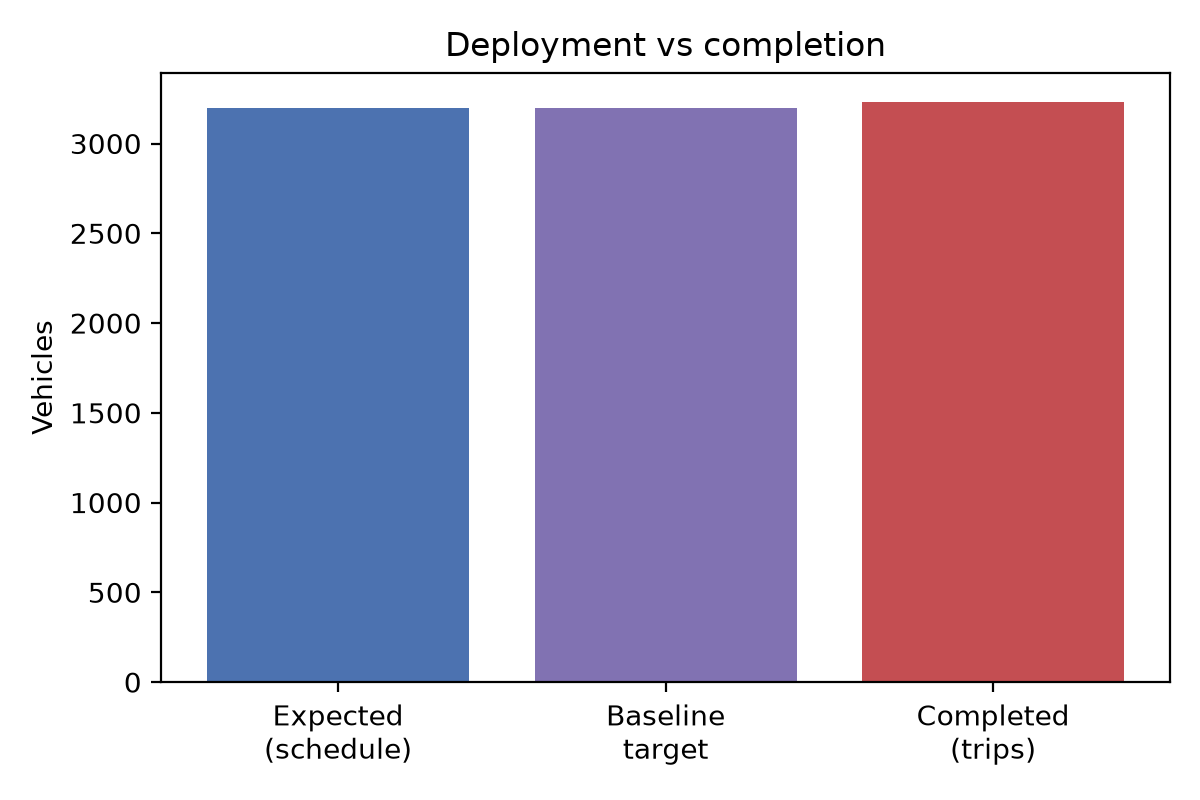

### Evacuation curve

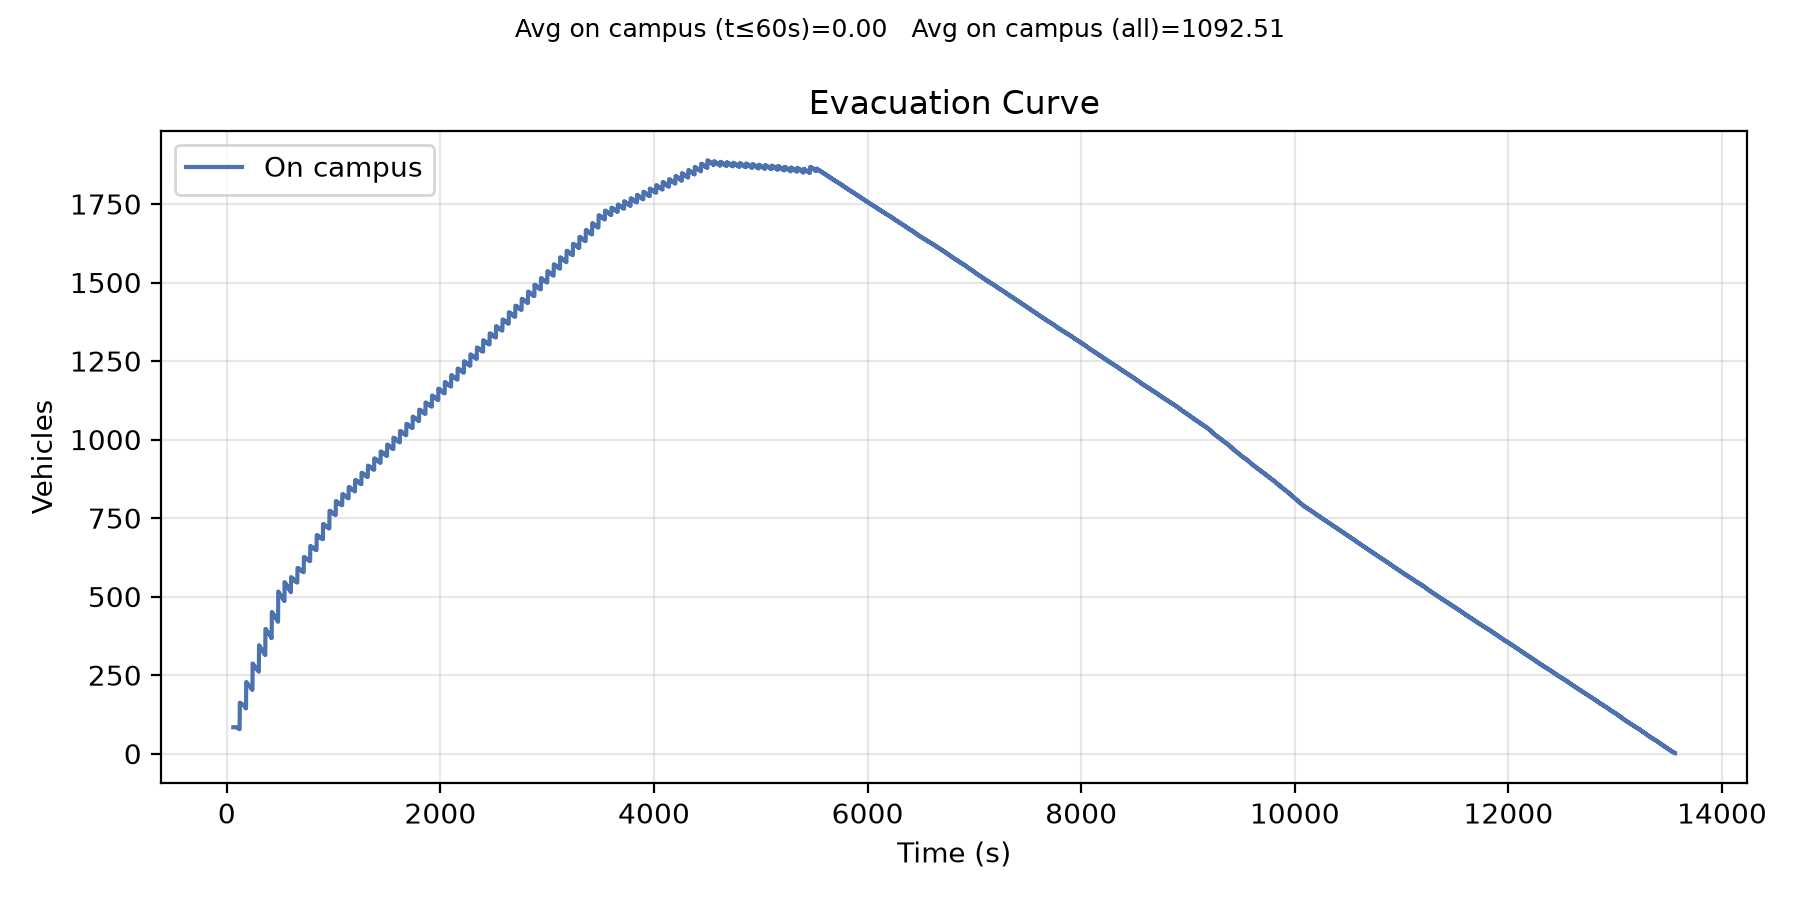

### Travel-time summary

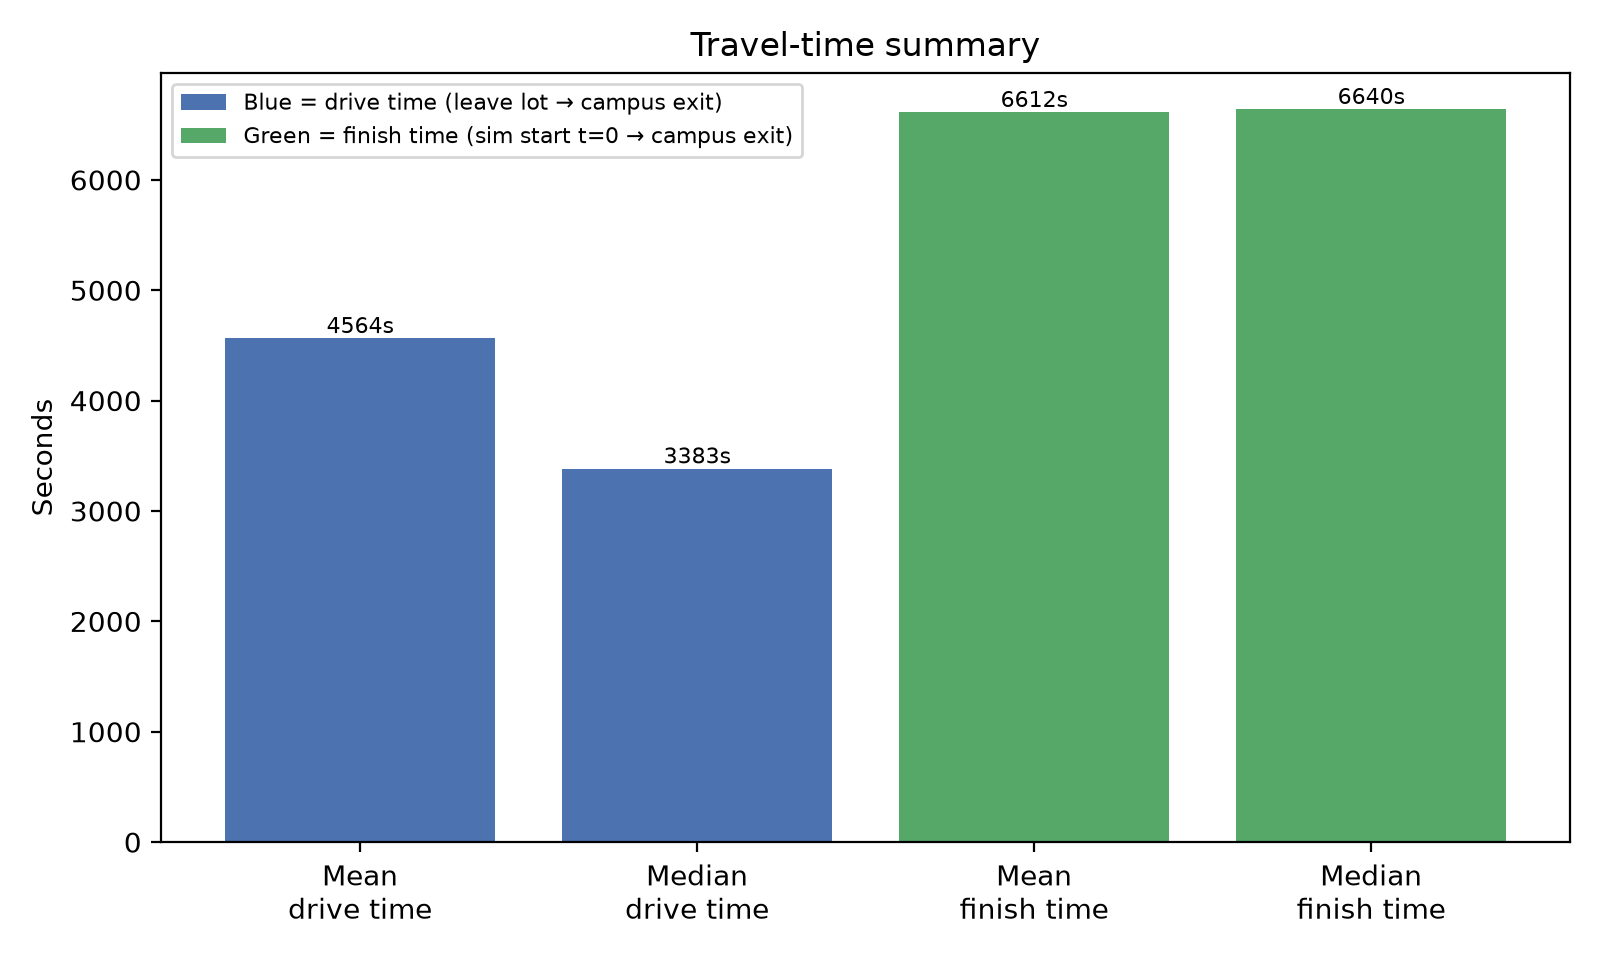

### Travel-time distribution

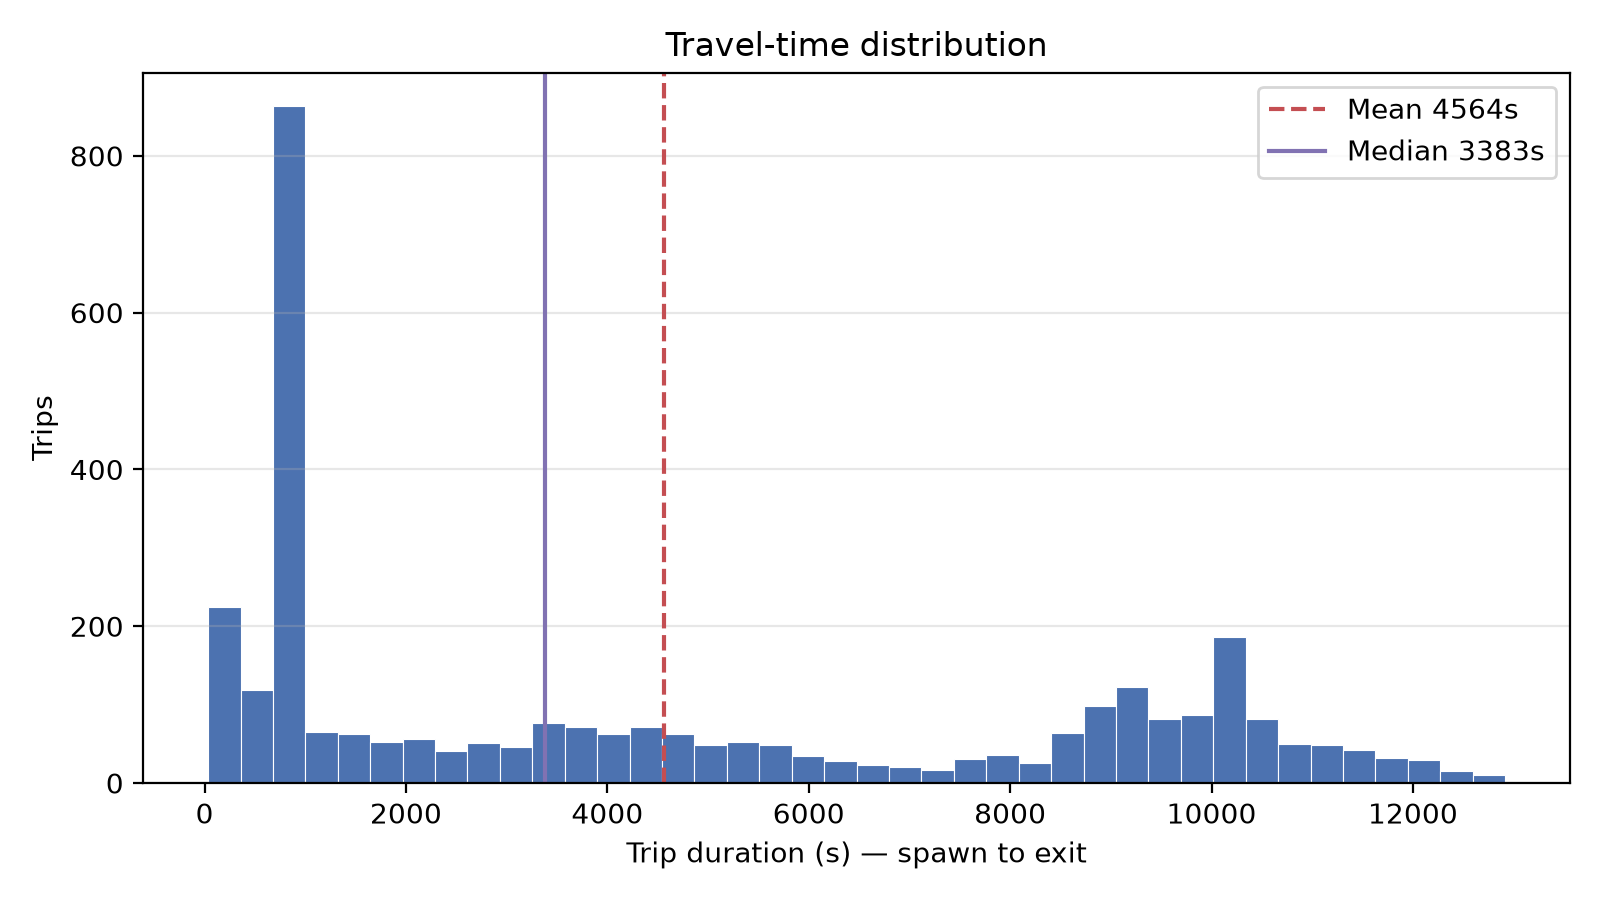

### Clearance by lot

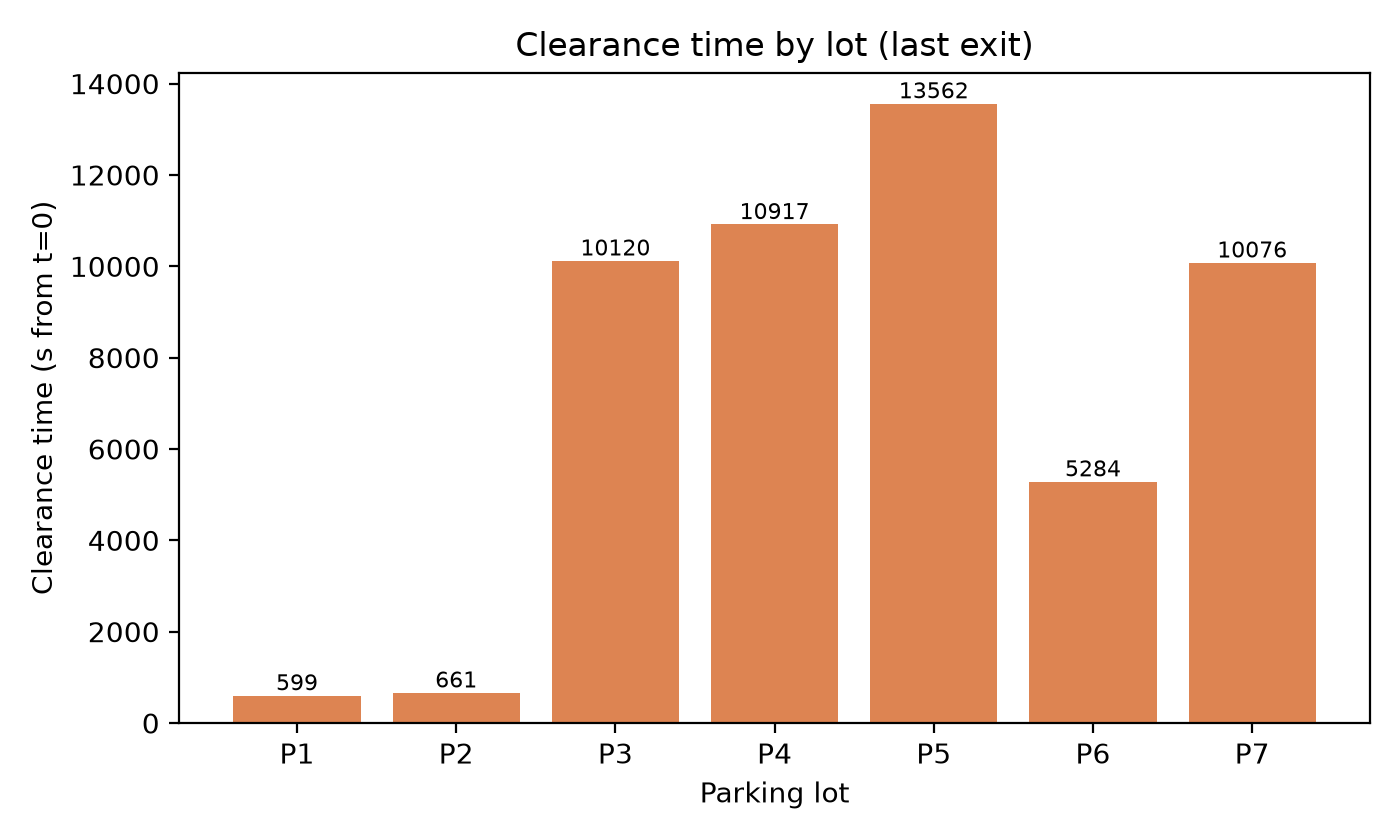

### Per-lot completion

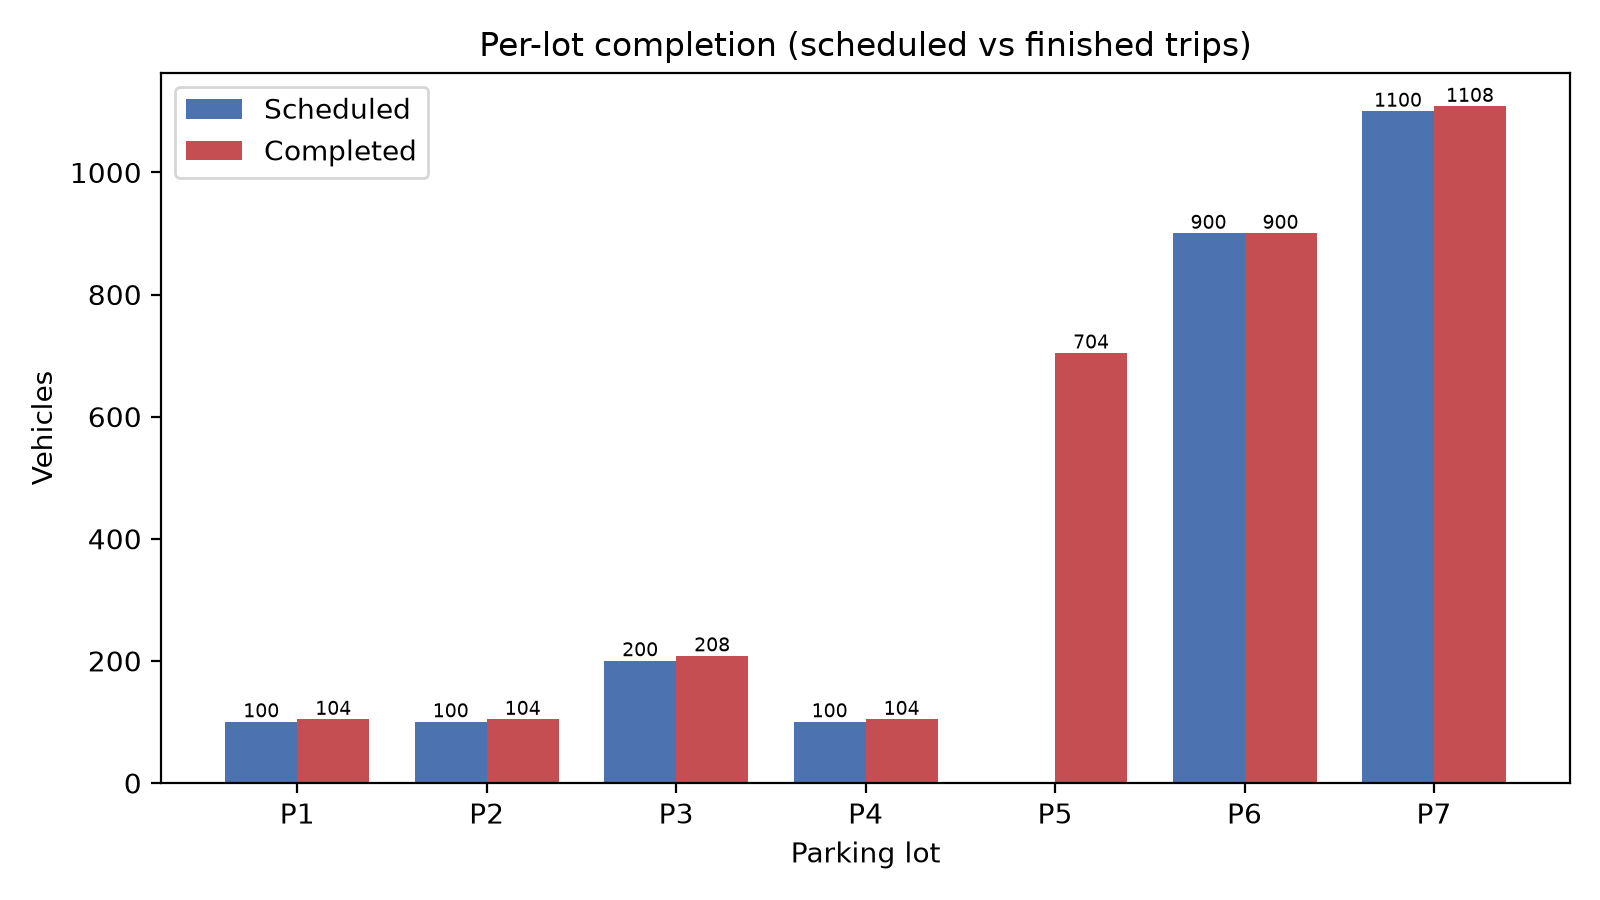

### Exit usage

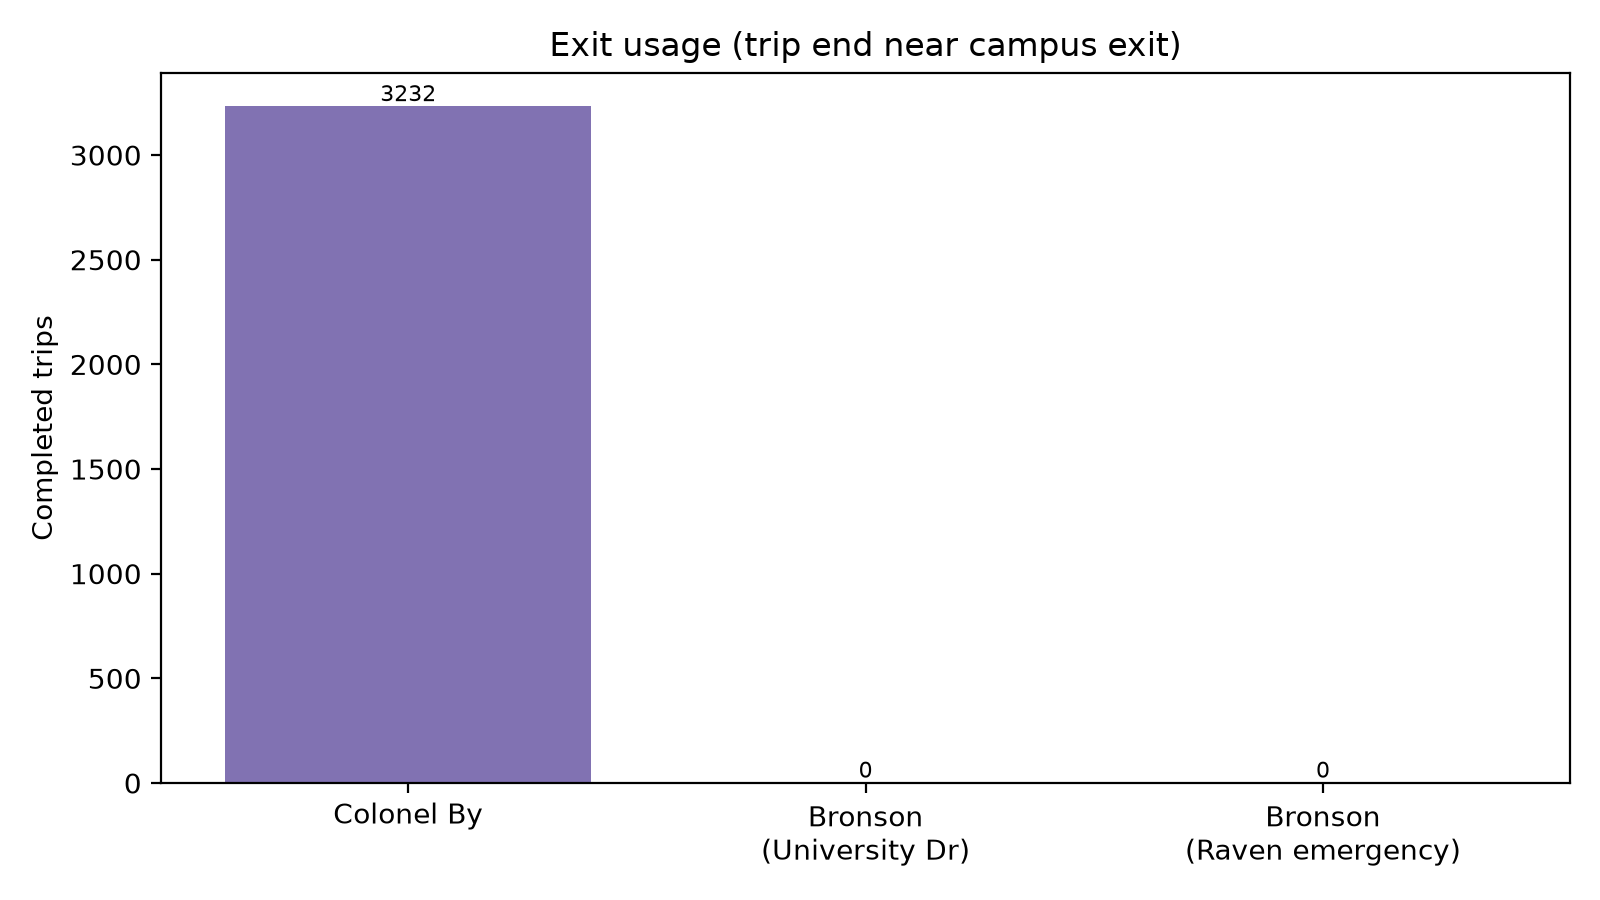

Missing chart: heatmap_matrix.png


In [11]:
if not CSV_PATH.is_file():
    raise FileNotFoundError(f"No CSV at {CSV_PATH}. Set RUN_SIMULATION = True and re-run.")

if RUN_HEATMAP:
    run_cmd([sys.executable, str(SCRIPTS / "analyze_and_heatmap.py"), str(CSV_PATH)])
else:
    run_cmd([sys.executable, str(SCRIPTS / "analyze_run.py"), str(CSV_PATH)])

summary_csv = OUT_DIR / "summary.csv"
if summary_csv.is_file():
    display(Markdown("### Summary"))
    print(summary_csv.read_text(encoding="utf-8"))

metrics_json = OUT_DIR / "metrics.json"
if metrics_json.is_file():
    display(Markdown("### metrics.json"))
    print(metrics_json.read_text(encoding="utf-8")[:2000])

for name, title in {
    "summary.png": "### Deployment",
    "evac_curve.png": "### Evacuation curve",
    "trip_time_stats.png": "### Travel-time summary",
    "trip_time_hist.png": "### Travel-time distribution",
    "clearance_by_lot.png": "### Clearance by lot",
    "completion_by_lot.png": "### Per-lot completion",
    "exit_usage.png": "### Exit usage",
    "heatmap_matrix.png": "### Heatmap",
}.items():
    path = OUT_DIR / name
    if path.is_file():
        display(Markdown(title))
        display(Image(filename=str(path)))
    else:
        print(f"Missing chart: {name}")

**Step 5** — Plot one sample route per parking lot (P1–P7) to its campus exit.

Writes `results/scenario_XX/agent_routes/P*_to_exit.png`. Skipped when `RUN_ROUTES = False`.

In [ ]:
if RUN_ROUTES:
    run_cmd(
        [
            sys.executable,
            str(SCRIPTS / "plot_agent_routes.py"),
            SID,
            "--one-per-lot",
        ],
        label="Plotting one route per lot (P1–P7)…",
    )
    for lot in ["P1", "P2", "P3", "P4", "P5", "P6", "P7"]:
        path = ROUTES_DIR / f"{lot}_to_exit.png"
        if path.is_file():
            display(Markdown(f"### {lot} → exit"))
            display(Image(filename=str(path)))
        else:
            print(f"Missing route plot: {path.name}")
else:
    print("Route plots skipped (RUN_ROUTES is False).")

Plotting one route per lot (P1–P7)…
